# 💳 CreditSure Analytics

## Intelligent Credit Risk Prediction Using Machine Learning

### *Turning Data into Smarter Lending Decisions*

**Author: Nelvin Bett**

---

## Project Overview

CreditSure Analytics is a machine learning project developed to predict the likelihood of loan default using historical borrower information. By analysing applicant demographics, financial characteristics, employment history, and loan details, the project aims to support more informed and consistent lending decisions.

The project follows a complete data science workflow, including business understanding, data exploration, preprocessing, model development, model evaluation, and model persistence.

### Dataset Source

This project uses the **Loan Default Dataset** obtained from Kaggle.

https://www.kaggle.com/datasets/nikhil1e9/loan-default

# 1. Business Understanding

Financial institutions face the challenge of balancing profitable lending with the risk of borrower default. Approving loans for high-risk applicants can lead to financial losses, while rejecting creditworthy applicants may reduce business opportunities.

Machine learning provides a data-driven approach to assessing credit risk by learning patterns from historical loan data and supporting more informed lending decisions.

## Business Problem

The objective of this project is to develop a machine learning model capable of predicting whether a borrower is likely to default on a loan.

Accurate prediction of credit risk can help financial institutions improve lending decisions, minimise default rates, and strengthen overall risk management.

## Project Objectives

The objectives of this project are to:

- Understand the dataset and its variables.
- Assess the quality of the data.
- Explore patterns associated with loan default.
- Prepare the data for machine learning.
- Train and compare multiple classification models.
- Select and save the best-performing model.

# 2. Importing Libraries

The following libraries are imported to support data manipulation, visualisation, preprocessing, model development, and evaluation throughout the project.

In [1]:
#importing neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score, recall_score, precision_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


# 3. Loading the Dataset

The dataset is loaded into the notebook and inspected to understand its structure before any analysis is performed.

In [2]:
#The dataset is loaded into a Pandas DataFrame to enable exploration and analysis
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Nelvin\Desktop\Mentee\Mentee Cohort 4\Project 1\Credit Risk\Loan_default.csv"
)

print(df.shape)
df.head()

(255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# 4. Data Understanding

Data understanding involves examining the structure and contents of the dataset before cleaning or modelling. This helps identify the available variables, their data types, and provides an overview of the information available for analysis.

In [3]:
# Display the first five records
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# Display the dimensions of the dataset
df.shape

(255347, 18)

In [5]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


### Summary

The dataset contains **255,347 loan applications** described by **18 variables**, including applicant demographics, financial information, employment history, and loan characteristics.

The target variable, **Default**, indicates whether a borrower defaulted on a loan, making this a **binary classification** problem.

At first glance, the dataset appears complete and structured, providing a strong foundation for exploratory analysis and predictive modelling.

# 5. Data Dictionary

The dataset consists of applicant information, financial details, loan characteristics, and the target variable. Understanding the purpose of each variable helps in interpreting the analysis and selecting appropriate features for model development.

In [6]:
# Display all column names
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

| Variable | Description |
|----------|-------------|
| LoanID | Unique identifier for each loan application. |
| Age | Age of the applicant. |
| Income | Annual income of the applicant. |
| LoanAmount | Amount of the loan requested. |
| CreditScore | Creditworthiness score of the applicant. |
| MonthsEmployed | Number of months the applicant has been employed. |
| NumCreditLines | Number of active credit accounts. |
| InterestRate | Interest rate charged on the loan. |
| LoanTerm | Duration of the loan in months. |
| DTIRatio | Debt-to-Income ratio of the applicant. |
| Education | Highest education level attained. |
| EmploymentType | Employment category of the applicant. |
| MaritalStatus | Marital status of the applicant. |
| HasMortgage | Indicates whether the applicant has an existing mortgage. |
| HasDependents | Indicates whether the applicant has dependents. |
| LoanPurpose | Purpose of the loan. |
| HasCoSigner | Indicates whether the applicant has a co-signer. |
| Default | Target variable indicating whether the applicant defaulted (1) or not (0). |

# 6. Data Quality Assessment

Before exploring the data and building machine learning models, it is important to assess the quality of the dataset. Poor data quality can lead to inaccurate analysis and unreliable model predictions.

In this section, the dataset is checked for:

- Missing values
- Duplicate records
- Appropriate data types

These checks help ensure the data is suitable for analysis and identify any preprocessing that may be required before modelling.

In [7]:
# Check for missing values
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [9]:
# Check data types
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

### Findings

The data quality assessment shows that the dataset contains **no missing values** and **no duplicate records**, indicating a high level of completeness and consistency.

The variables are stored using appropriate data types, with numerical features ready for analysis and categorical variables requiring encoding before model training.

# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, understand the distribution of variables, and identify relationships within the dataset.

The goal is not only to understand the characteristics of the loan applicants but also to gain insights that will guide feature preparation and model development.

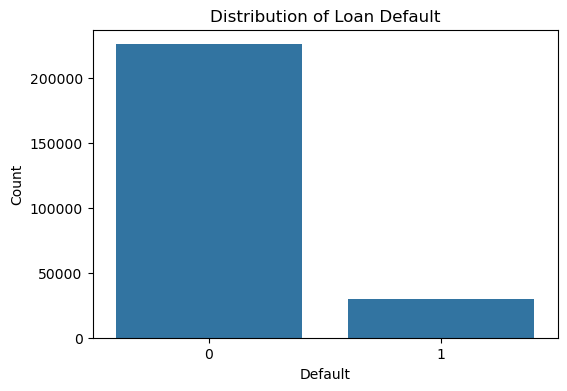

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Default")

plt.title("Distribution of Loan Default")
plt.xlabel("Default")
plt.ylabel("Count")

plt.show()

### Findings

The distribution shows that **most loan applicants did not default**, while a much smaller proportion defaulted on their loans. This indicates that the target variable is **imbalanced**, meaning the model will be trained on considerably more non-default cases than default cases.

As a result, relying solely on **Accuracy** may give a misleading impression of model performance. Metrics such as **Precision, Recall, and F1 Score** will therefore be used alongside Accuracy to provide a more balanced evaluation of the classification models.

## Distribution of Key Numerical Variables

Understanding the distribution of key applicant characteristics provides an overview of the borrower population and helps identify differences in financial profiles. These insights support data preparation and provide context for the predictive models developed later in this project.

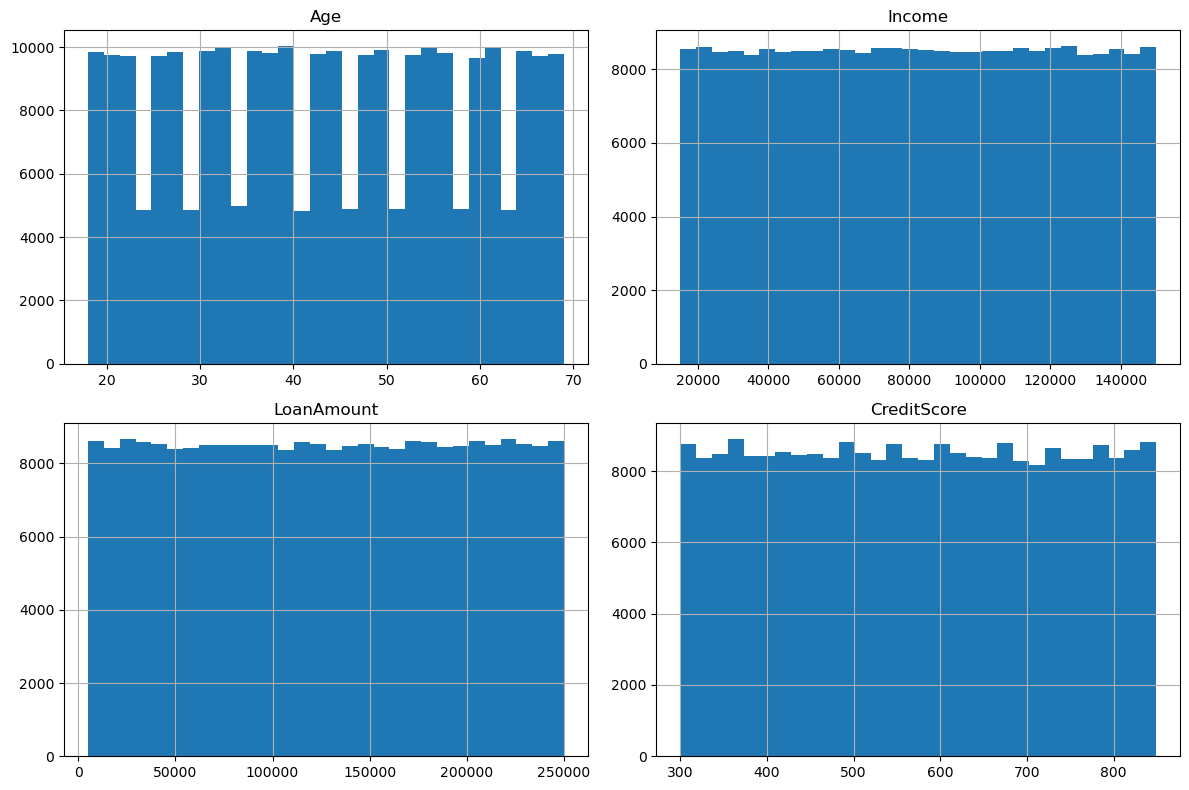

In [11]:

# Select the key numerical variables for analysis
key_numerical = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore"
]

# Plot histograms to examine the distribution of each variable
df[key_numerical].hist(
    figsize=(12, 8),
    bins=30
)

# Adjust spacing between plots
plt.tight_layout()

# Display the histograms
plt.show()

### Findings

The four key numerical variables are broadly distributed across their respective ranges, indicating that the dataset includes applicants with diverse demographic and financial profiles. No single range appears to dominate the distributions, suggesting that the dataset captures a wide variety of borrower characteristics.

The variables are measured on different scales—for example, income and loan amount have much larger values than age and credit score. This difference will be addressed during data preprocessing through feature scaling before training the machine learning models.

## 7.3 Correlation Analysis

Correlation analysis examines the strength and direction of linear relationships between numerical variables. This helps identify whether features are highly related to one another, which can influence feature selection and model performance.

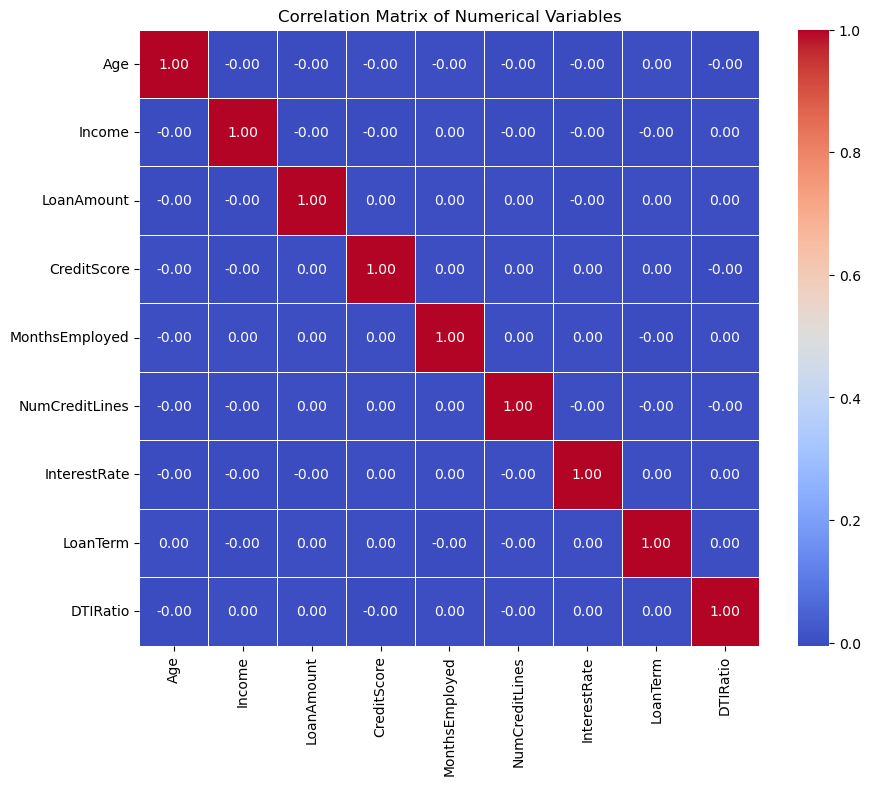

In [12]:
# Select only the numerical columns (excluding the target variable)
numerical_df = df.select_dtypes(include=["int64", "float64"]).drop(columns="Default")

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create the correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Add a title
plt.title("Correlation Matrix of Numerical Variables")

# Display the heatmap
plt.show()

### Findings

The correlation matrix shows that the numerical variables have **very weak linear relationships** with one another, with most correlation coefficients close to **zero**. This indicates that the features provide largely independent information rather than being strongly related.

From this analysis, there is **no evidence of significant multicollinearity** among the numerical variables.

## 7.4 Outlier Detection

Boxplots are used to examine the spread of the numerical variables and identify potential outliers. Detecting unusual values helps us understand the distribution of the data and determine whether additional preprocessing may be required before model training.

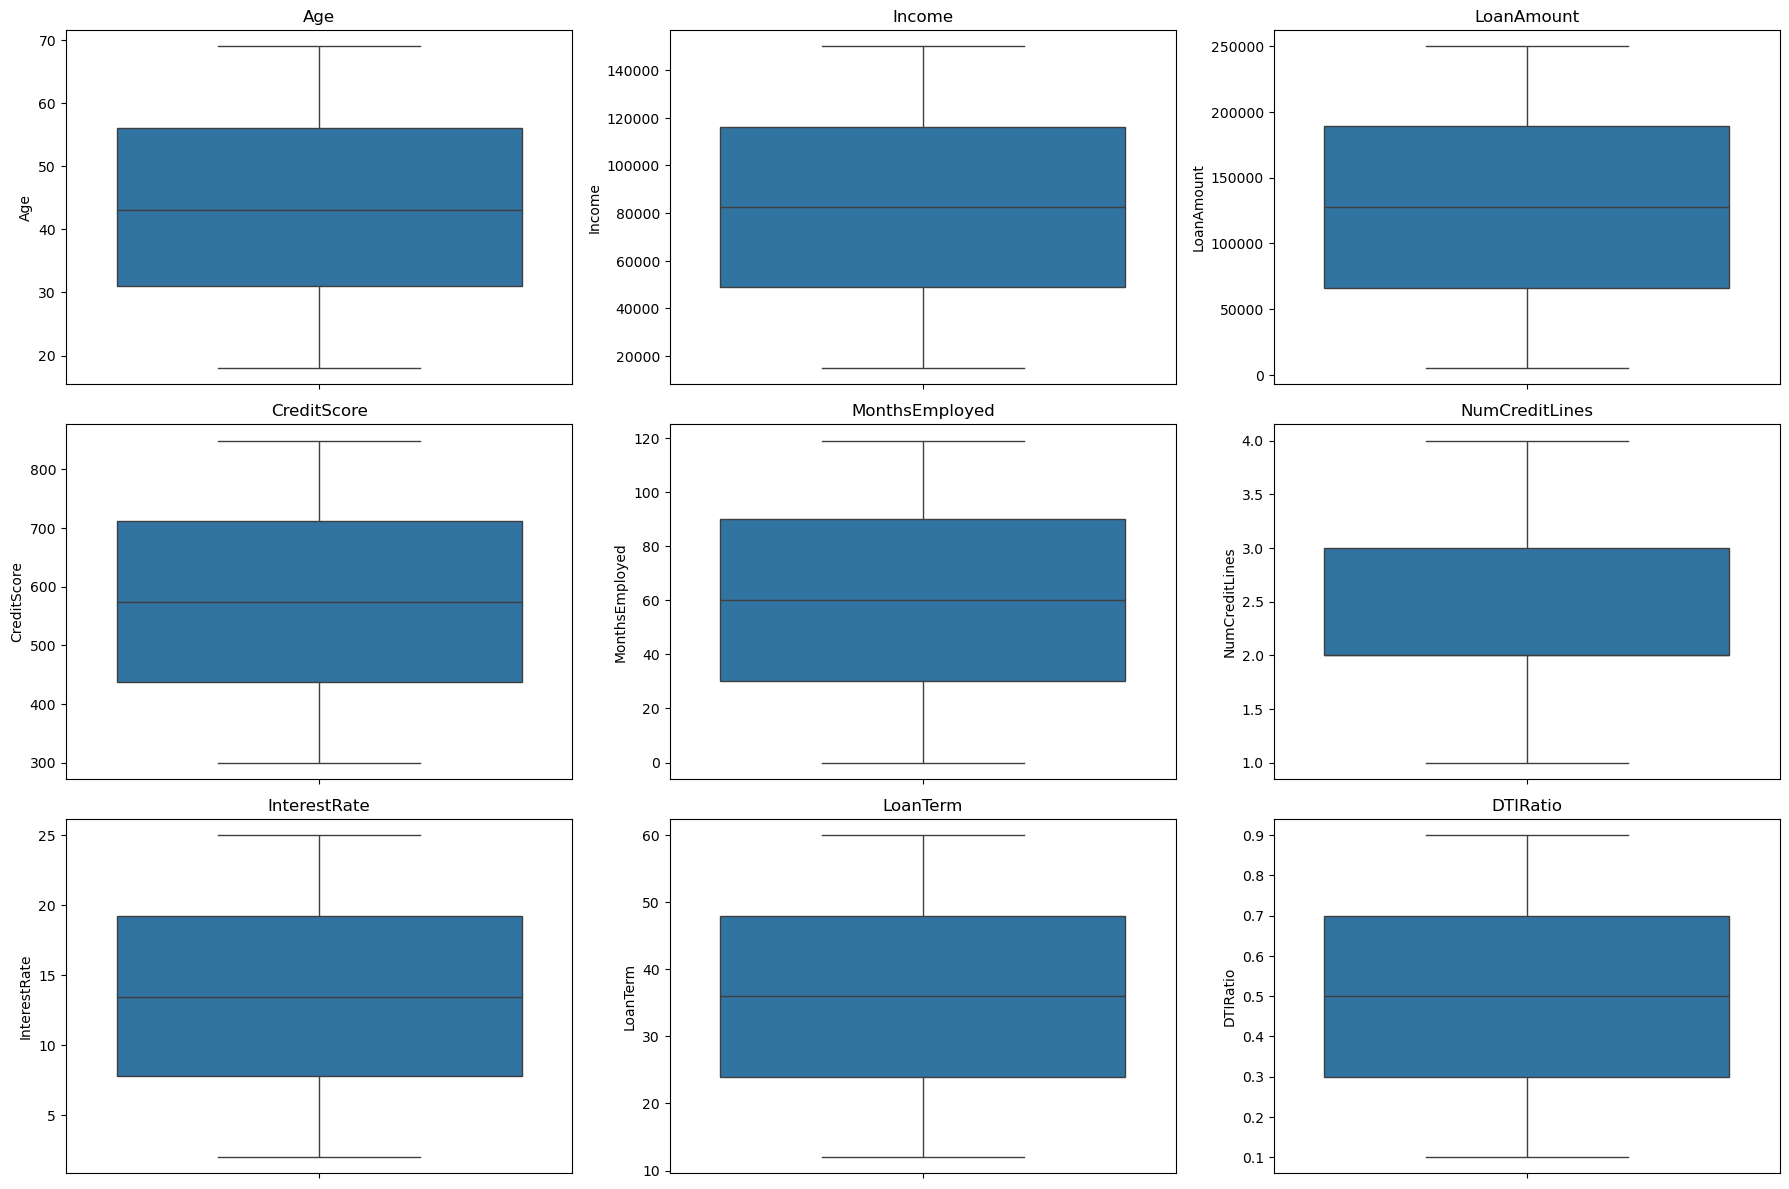

In [13]:
# Select only the numerical columns (excluding the target variable)
numerical_df = df.select_dtypes(include=["int64", "float64"]).drop(columns="Default")

# Create boxplots for each numerical variable
plt.figure(figsize=(18, 12))

# Plot a boxplot for each numerical feature
for i, column in enumerate(numerical_df.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=numerical_df[column])
    plt.title(column)

# Adjust spacing between plots
plt.tight_layout()

# Display the boxplots
plt.show()

### Findings

The boxplots show that the numerical variables are generally well distributed, with no obvious extreme outliers visible across the features. This suggests that the dataset is relatively consistent and does not appear to require immediate outlier treatment before model development.

Although the variables differ in scale, their overall distributions remain stable and suitable for the preprocessing steps that follow.

### EDA Summary

The exploratory analysis provided an overview of the dataset and confirmed that it is well structured for machine learning. The target variable is imbalanced, the key numerical variables cover a broad range of applicant characteristics, the numerical features show very weak linear relationships, and no obvious extreme outliers were observed.

With these insights, the next step is to prepare the data for model development through preprocessing and feature engineering.

# 8. Data Preprocessing

Before training machine learning models, the dataset must be prepared in a format suitable for analysis. This includes removing variables that do not contribute to prediction, converting categorical variables into numerical format, splitting the data into training and testing sets, and scaling the numerical features where necessary.

## Removing the Identifier Column

The **LoanID** column uniquely identifies each loan application but does not contain information that helps predict whether a borrower will default. It is therefore removed before model training.

In [14]:
# Remove the LoanID column since it is not a predictive feature
df = df.drop("LoanID", axis=1)

# Display the first five rows of the updated dataset
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## Defining Features and Target Variable

The dataset is divided into:

- **Features (X):** The independent variables used to predict loan default.
- **Target (y):** The **Default** variable, which indicates whether a borrower defaulted on a loan.

In [15]:
# Separate the predictor variables from the target variable
X = df.drop("Default", axis=1)
y = df["Default"]

# Display the dimensions of the feature matrix and target variable
print("Features:", X.shape)
print("Target:", y.shape)

Features: (255347, 16)
Target: (255347,)


### Encoding Categorical Variables

Most machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical values using one-hot encoding while preserving the information contained in each category.

In [16]:
# Convert categorical variables into numerical variables using one-hot encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

# Display the dimensions of the encoded feature matrix
print("Encoded Features:", X.shape)

# Display the encoded categorical columns
encoded_columns = [col for col in X.columns if "_" in col]
print(encoded_columns)

Encoded Features: (255347, 24)
['Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCoSigner_Yes']


### Findings

One-hot encoding successfully converted the categorical variables into numerical features, increasing the number of predictor variables from **17** to **24**. The newly created columns represent the encoded categories and prepare the dataset for machine learning algorithms.

## Splitting the Dataset

To evaluate how well the models generalise to unseen data, the dataset is divided into training and testing sets. The training set is used to build the models, while the testing set is reserved for evaluating their performance.

In [17]:
# Import the function used to split the dataset
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the dimensions of the training and testing sets
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (204277, 24)
Testing set: (51070, 24)


### Findings

The dataset was successfully split into training and testing sets using an 80:20 ratio. This ensures that model performance is evaluated on unseen data, providing a more reliable assessment of its predictive ability.

### Feature Scaling

The numerical variables are standardised to ensure they are measured on a comparable scale. This improves the performance of algorithms that are sensitive to differences in feature magnitude.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Findings

The numerical features were successfully standardised using **StandardScaler**. Scaling ensures that features measured on different ranges contribute more consistently during model training, particularly for algorithms that are sensitive to feature magnitude.

# 9. Model Development

With the data prepared, the next step is to train machine learning models to predict whether a borrower is likely to default on a loan.

Three classification algorithms are evaluated and compared using the same training and testing datasets. Their performance is assessed using multiple evaluation metrics to identify the model that best suits this prediction task..

## Training and Evaluating the Models

Each model is trained using the training dataset and evaluated on the testing dataset. The models are compared using Accuracy, Precision, Recall, and F1 Score to determine which algorithm performs best for predicting loan default.

In [24]:
# Define the machine learning models to be evaluated
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Create an empty list to store the evaluation results
results = []

# Train and evaluate each model
for name, model in models.items():

    # Train the model using the training data
    model.fit(X_train_scaled, y_train)

    # Generate predictions on the testing data
    y_pred = model.predict(X_test_scaled)

    # Calculate and store the evaluation metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)

# Display the model comparison table
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.885823,0.608833,0.032712,0.062088
1,Random Forest,0.886117,0.661538,0.029153,0.055844
2,Gradient Boosting,0.887174,0.648707,0.051017,0.094595


### Findings

All three models achieved similar levels of accuracy, indicating that each performed well in classifying the majority of loan applications. However, Accuracy alone does not provide a complete assessment because the target variable is imbalanced.

To identify the most suitable model, the Precision, Recall, and F1 Score are also compared in the next section.

### Model Performance Summary

The table above compares the performance of the three classification models. Rather than relying on a single metric, multiple evaluation measures are considered to provide a balanced assessment of each model's predictive performance.

In [20]:
# Rank models by F1 Score
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Gradient Boosting,0.887174,0.648707,0.051017,0.094595
0,Logistic Regression,0.885823,0.608833,0.032712,0.062088
1,Random Forest,0.886117,0.661538,0.029153,0.055844


## Final Model Selection

Based on the model comparison, **Gradient Boosting** achieved the highest F1 Score and was selected as the final model for CreditSure Analytics.

The selected model is retrained using the training data before being saved for future predictions.

In [21]:
# Create the final Gradient Boosting model
best_model = GradientBoostingClassifier(
    random_state=42
)

# Train the model using the training dataset
best_model.fit(
    X_train_scaled,
    y_train
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [22]:
# Generate predictions using the trained model
y_pred = best_model.predict(
    X_test_scaled
)

print("Final Model: Gradient Boosting")

Final Model: Gradient Boosting


## Saving the Model

Saving the trained model allows it to be reused without repeating the training process. This is useful when deploying the model or using it to make predictions on new loan applications.

In [23]:
# Import Joblib
import joblib

# Save the trained model
joblib.dump(
    best_model,
    "credit_risk_model.pkl"
)

['credit_risk_model.pkl']

### Confirmation

The trained model has been saved as **credit_risk_model.pkl** and can be loaded later to make predictions on new loan applications without retraining.

# 10. Conclusion

CreditSure Analytics successfully demonstrates how machine learning can be applied to predict loan default using borrower demographic, financial, employment, and loan-related information.

The project followed a structured data science workflow, beginning with business understanding and data exploration, followed by preprocessing, model development, evaluation, and model persistence.

Among the three classification models evaluated, **Gradient Boosting** achieved the highest F1 Score and was selected as the final model. The completed workflow provides a practical example of how predictive analytics can support credit risk assessment using historical lending data.

# 11. Business Recommendations

Based on the findings from this project, the following recommendations can support more effective credit risk management:

- Use the trained model as a decision-support tool during the loan approval process rather than replacing human judgement.
- Continuously retrain the model using updated lending data to maintain predictive performance over time.
- Monitor model performance regularly to ensure predictions remain reliable as customer behaviour and economic conditions change.
- Consider additional feature engineering and model tuning to improve the identification of borrowers who are likely to default.

# 12. Final Remarks

This project demonstrates the complete development of a machine learning solution for credit risk prediction, from understanding the business problem to selecting and saving the final model.

Beyond building a predictive model, the project highlights the importance of structured data preparation, thoughtful model evaluation, and selecting appropriate performance metrics for an imbalanced classification problem.

The workflow developed in CreditSure Analytics provides a solid foundation that can be extended with additional data, feature engineering, and model optimisation in future work.